In [18]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src import features
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

from src import synthetic

FORECAST_HORIZON = 5

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)



from pandas.tseries.offsets import DateOffset


def split_Xy(df, forecast_horizon):
    """Split a dataframe into features X and targets y.

    Closed-day sales (zeros) are first replaced by interpolated values so that
    lag/rolling features can be computed across those days.  The Sales column is
    then differenced with a lag of ``forecast_horizon``, so each target value is:

        y[t] = interpolated_sales[t + forecast_horizon] - interpolated_sales[t]

    i.e. the ``forecast_horizon``-step-ahead *change* in (interpolated) sales.

    Features are then generated from the differenced sales using the same lags,
    rolling windows, and differences plus store-related features.
    """

    sales_interp = utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
    df['Sales'] = sales_interp.groupby(level='Store').diff(periods=forecast_horizon)

    X = make_features(df, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)
    y = make_targets(df['Sales'], forecast_horizon)
    X, y = drop_null_targets(X, y)
    
    return X, y



# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

 DayOfWeek  Open  Promo StateHoliday  SchoolHoliday      Sales StoreType Assortment  CompetitionDistance CompetitionSinceDate Promo2SinceDate   PromoInterval  Promo2  isStateHoliday  isSchoolHoliday CompetitionStartDate
         2     1      0    NoHoliday              0 467.320508         a          a                500.0           2012-04-01      2012-07-01 Jan,Apr,Jul,Oct       1           False            False           2012-04-01
         3     1      0            a              0 467.820508         a          a                500.0           2012-04-01      2012-07-01 Jan,Apr,Jul,Oct       1            True            False           2012-04-01
         4     1      0    NoHoliday              1 451.000000         a          a                500.0           2012-04-01      2012-07-01 Jan,Apr,Jul,Oct       1           False             True           2012-04-01
         5     1      0    NoHoliday              0 434.179492         a          a                500.0           2012-

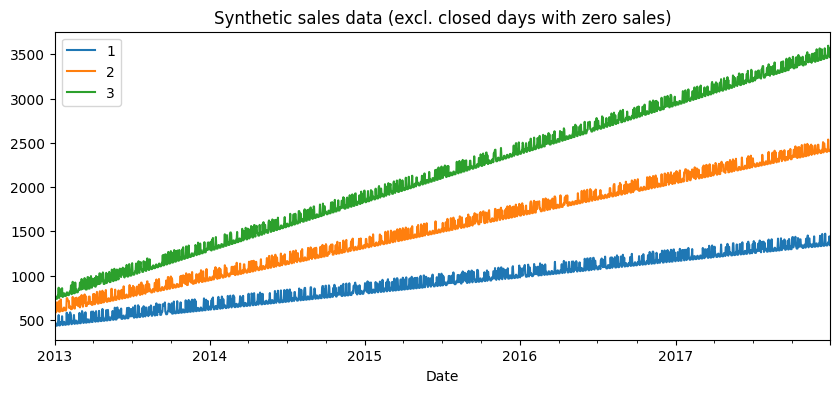

In [19]:
NUM_STORES = 3
NUM_DAYS = 365 * 5

stores = synthetic.store_data(n_stores=NUM_STORES)
sales = synthetic.sales_data(n_stores=NUM_STORES, days=NUM_DAYS)
df = sales.merge(stores, on='Store', how='left').set_index(['Store', 'Date']).sort_index(ascending=True)  # Ensure chronological order (NOT NEEDED FOR THE FEATURES WE'LL GENERATE, BUT GOOD PRACTICE IN GENERAL)

no_state_holiday = df['StateHoliday'].isin(['0', 0]) | df['StateHoliday'].isna()
df.loc[no_state_holiday, 'StateHoliday'] = 'NoHoliday'
df['isStateHoliday'] = df['StateHoliday'] != 'NoHoliday'
df['isSchoolHoliday'] = df['SchoolHoliday'].astype(bool)

df['CompetitionStartDate'] = df['CompetitionSinceDate'].apply(lambda x: pd.to_datetime(x) if pd.notnull(x) else pd.NaT)

df.loc[df['Sales'] == 0, 'Sales'] = np.nan
df.ffill(inplace=True)  # Fill NaN values with the last valid observation



cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "inner_train_size": 1000, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

print(df.head(5).to_string(index=False))

(
    df
    .loc[df['Sales'] > 0]
    .reset_index()
    .set_index("Date")
    .groupby("Store")["Sales"]
    .plot(figsize=(10, 4),
          title="Synthetic sales data (excl. closed days with zero sales)",
          legend=True)
)

plt.savefig(os.path.join(C.LOG_DIR, "training_set.png"))

In [20]:
""" 
# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. First-order differencing on the Sales column to make the series more stationary
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)

df_processed = df.copy()
df_processed['Sales'] = (
    utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
    .groupby(level='Store')
    .diff()
)
X = make_features(df_processed, lags, rolling_windows, diffs)
y = make_targets(df_processed['Sales'], FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                  horizon=cv_config["forecast_horizon"],
                  train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = utils.predict(booster, X_test)

    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = (utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
               .loc[origin_index]
               .set_axis(preds.index))
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    
    # Log metrics and artifacts
    actuals = utils.retrieve_sales(df['Sales'], preds.index)
    metrics = compute_metrics(actuals.values, preds.values)
    logger.info(f"Test set metrics for fold {fold}: {metrics}")
    
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break
"""

' \n# Preprocessing steps:\n# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, \n#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)\n# 2. First-order differencing on the Sales column to make the series more stationary\n# 3. Create features and targets for the whole dataset\n# 4. Drop rows with null targets (i.e. those that don\'t have enough history\n#    to create all requested lags, rolls, diffs, and/or forecast horizon)\n\ndf_processed = df.copy()\ndf_processed[\'Sales\'] = (\n    utils.overwrite_closed_sales(df_processed[\'Sales\'], mode=\'interpolate\')\n    .groupby(level=\'Store\')\n    .diff()\n)\nX = make_features(df_processed, lags, rolling_windows, diffs)\ny = make_targets(df_processed[\'Sales\'], FORECAST_HORIZON)\nX, y = drop_null_targets(X, y)\n\ncv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],\n                  horizon=cv_config["forecast_horizon"],\n                  train_s

In [21]:
import xgboost as xgb
from src.engine import utils
from src.features.timeseries import lag_features
from src.engine.hypertuning import _objective
from optuna.trial import FixedTrial

FORECAST_HORIZON = 10
NUM_STORES = 4
NUM_DAYS = 365*4


lags = [pd.DateOffset(days=i) for i in range(1, 3)]
diffs = [pd.DateOffset(days=i) for i in range(1, 3)]
windows = ['7D', '14D', '30D']
forecast_steps = [pd.DateOffset(days=-i) for i in range(1, FORECAST_HORIZON+1)]
horizon = pd.DateOffset(days=FORECAST_HORIZON) # We use this to shift the features by the forecast
                                                   # horizon to align them with the target variable.



stores = synthetic.store_data(n_stores=NUM_STORES)
sales = synthetic.sales_data(n_stores=NUM_STORES, days=NUM_DAYS)
df = sales.merge(stores, on='Store', how='left')
df = df.sort_index(ascending=True) # Sort by Store and Date to ensure chronological order for feature engineering 

no_state_holiday = df['StateHoliday'].isin(['0', 0]) | df['StateHoliday'].isna()
df.loc[no_state_holiday, 'StateHoliday'] = 'NoHoliday'
df['isStateHoliday'] = df['StateHoliday'] != 'NoHoliday'
df['isSchoolHoliday'] = df['SchoolHoliday'].astype(bool)
df['CompetitionStartDate'] = df['CompetitionSinceDate'].apply(lambda x: pd.to_datetime(x) if pd.notnull(x) else pd.NaT)

# Interpolate sales for closed days to create anchors for inverting the differencing and log transformation on the predictions, so that we can get them back on the original scale for evaluation and plotting.
is_closed = df['Date'].dt.day_name() == 'Sunday'
df_nc = df.copy()
df_nc.loc[is_closed, 'Sales'] = np.nan
df_nc = (df_nc
         .set_index(['Date', 'Store'])
         .groupby(level='Store', group_keys=False)
         .apply(lambda x: x.interpolate(method='linear'))
         .reset_index())

grouped = df_nc.set_index(['Date']).groupby('Store')

X = grouped.apply(lambda df: features.compute(df, lags, diffs, windows, horizon))

# Create target variable by applying the same lag_features function to the Sales column, 
# but with a negative lag equal to the forecast horizon, to get the future sales value we want to predict. 
y_init = grouped['Sales'].apply(lag_features, lags=[pd.DateOffset(days=-FORECAST_HORIZON)])

# We also apply log1p transformation to stabilize variance and make the distribution more normal.
y_log = y_init.apply(np.log1p)

# First order differencing to make the series more stationary, which is often beneficial for time series forecasting models.
# We compute the difference between today and the value we want to forecast (i.e. the value at the forecast horizon). 
# This helps the model focus on predicting changes in sales rather than absolute values, which can be more stable and easier to learn.
y_diff = y_log.diff(periods=FORECAST_HORIZON)


notna_targets = pd.notna(y_diff).all(axis=1)  # Drop rows where any target column is NaN
X = X.iloc[notna_targets.values, :]
y = y_diff.iloc[notna_targets.values]


inner_cv = TimeSeriesCV(n_splits=C.N_INNER_SPLITS,
                        train_size=C.INNER_TRAIN_SIZE,
                        test_size=C.INNER_TEST_SIZE)


# Values must fall within the bounds defined in C.HYPERPARAMETERS
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.7,        # C.HYPERPARAMETERS bounds: [0.6, 1.0]
    'colsample_bytree': 0.7, # C.HYPERPARAMETERS bounds: [0.6, 1.0]
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}


mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                study_name='stuff',
                                study_config=study_config)

obj_fcn(mock_trial)


[0]	train-rmse:0.04057+0.00135	test-rmse:0.03584+0.00295
[100]	train-rmse:0.03960+0.00128	test-rmse:0.03481+0.00289
[200]	train-rmse:0.03871+0.00121	test-rmse:0.03389+0.00284
[300]	train-rmse:0.03800+0.00114	test-rmse:0.03314+0.00279
[400]	train-rmse:0.03740+0.00109	test-rmse:0.03251+0.00273
[500]	train-rmse:0.03686+0.00104	test-rmse:0.03194+0.00268
[600]	train-rmse:0.03637+0.00101	test-rmse:0.03143+0.00261
[700]	train-rmse:0.03594+0.00098	test-rmse:0.03097+0.00255
[800]	train-rmse:0.03556+0.00096	test-rmse:0.03056+0.00248
[900]	train-rmse:0.03520+0.00094	test-rmse:0.03019+0.00243
[1000]	train-rmse:0.03488+0.00092	test-rmse:0.02985+0.00237
[1100]	train-rmse:0.03461+0.00090	test-rmse:0.02957+0.00232
[1200]	train-rmse:0.03437+0.00089	test-rmse:0.02932+0.00227
[1300]	train-rmse:0.03416+0.00087	test-rmse:0.02910+0.00223
[1400]	train-rmse:0.03396+0.00085	test-rmse:0.02891+0.00219
[1500]	train-rmse:0.03380+0.00083	test-rmse:0.02875+0.00217
[1600]	train-rmse:0.03369+0.00081	test-rmse:0.02864+

np.float64(0.028440957748578615)

In [43]:
booster = hypertuning.refit(X, y, mock_trial, study_config)

test_dmatrix = xgb.DMatrix(X, enable_categorical=True)

# Predictions are currently on the differenced log scale, so they represent the predicted change in log sales over the forecast horizon. 
# We need to invert the differencing and log transformation to get predictions back on the original sales scale. 
preds_log_diff = booster.predict(test_dmatrix)
preds_log_diff = pd.Series(data=preds_log_diff, index=X.index)  # (Store, Date) MultiIndex

# Step 1: Build a (Store, Date) MultiIndex sales Series — same level order as preds, so no reorder needed.
sales = df.set_index(['Store', 'Date'])['Sales'].sort_index()  # Log-transform the sales to match the scale of the targets used for training

# Step 2: Log-transform the sales to match the scale of the targets used for training
sales_log = sales.apply(np.log1p)

# Step 3: Interpolate sales for closed days (Sundays) so that we have valid anchor
# values to invert the differencing and log transformation for predictions on those days.
# Use .copy() so sales_mi is not mutated and remains valid for actuals below.
sales_log_nc = sales_log.copy()
is_closed = sales_log_nc.index.get_level_values("Date").day_name() == 'Sunday'
sales_log_nc.loc[is_closed] = np.nan
sales_log_nc = (sales_log_nc
                .groupby(level='Store')
                .apply(lambda x: x.droplevel('Store').interpolate(method='linear')))

# Step 4: Inverse first-order differencing to get predictions back on the original scale.
# y_diff[t] = Sales[t + FORECAST_HORIZON] - Sales[t], so:
# preds[t] = diff_preds[t] + Sales[t]
anchors_log = sales_log_nc.loc[preds_log_diff.index]#.apply(np.log1p)
preds_log = anchors_log + preds_log_diff

# Step 5: Inverse log transformation to get predictions back on the original scale.
preds = np.expm1(preds_log)  # Inverse of log1p applied to the targets during training

# Step 6: Zero out predictions for closed days (Sundays)
is_closed_preds = preds.index.get_level_values("Date").day_name() == 'Sunday'
preds.loc[is_closed_preds] = 0


In [56]:
results = pd.DataFrame({
    'actuals': df.set_index(['Store', 'Date'])['Sales'],
    'predictions': preds
}).dropna().sort_index()

max_date = results.index.get_level_values("Date").max()
min_date = max_date - pd.Timedelta(days=180)
actuals_recent = results.loc[(slice(None), slice(min_date, max_date)), 'actuals']
preds_recent = results.loc[(slice(None), slice(min_date, max_date)), 'predictions']


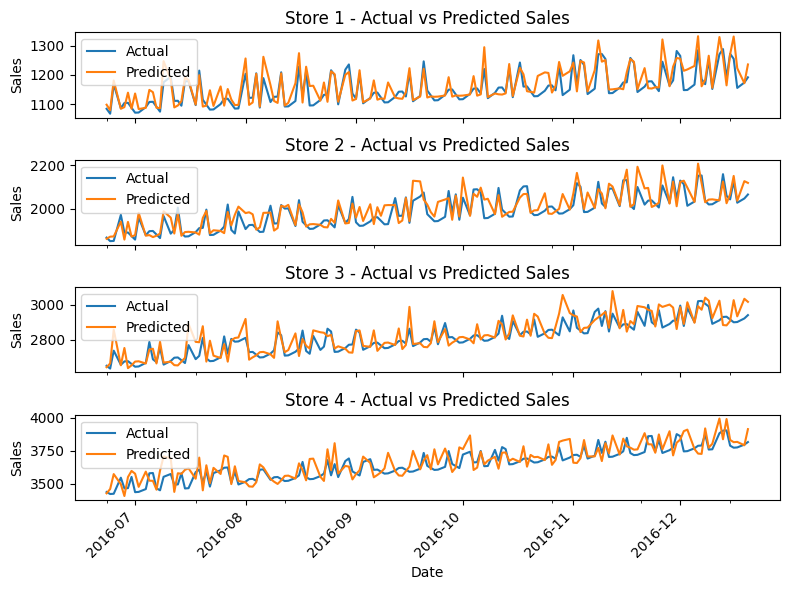

In [57]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates



stores = actuals_recent.index.get_level_values("Store").unique()
fig, ax = plt.subplots(figsize=(8, 6), nrows=len(stores), sharex=True, sharey=False)

for i, store in enumerate(stores):

    actual_store_sales = actuals_recent.loc[(store, slice(None))]
    predicted_store_sales = preds_recent.loc[(store, slice(None))]
    
    # exclude closed days with zero sales and zero predictions
    actual_store_sales = actual_store_sales[actual_store_sales > 0]
    predicted_store_sales = predicted_store_sales[predicted_store_sales > 0]

    actual_store_sales.plot(label=f"Actual", ax=ax[i])
    predicted_store_sales.plot(label=f"Predicted", ax=ax[i])
    
    ax[i].legend()
    ax[i].set_title(f"Store {store} - Actual vs Predicted Sales")
    ax[i].set_ylabel("Sales")
    
# Rotate x labels and set date format
ax[-1].xaxis.set_major_locator(mdates.MonthLocator())
ax[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax[-1].set_xlabel("Date")
plt.tight_layout()


In [34]:
actual_store_sales

Date
2016-09-21    3635.320508
2016-09-22    3620.000000
2016-09-23    3604.679492
2016-09-24    3606.679492
2016-09-25       0.000000
                 ...     
2016-12-16    3772.679492
2016-12-17    3774.679492
2016-12-18       0.000000
2016-12-19    3796.000000
2016-12-20    3815.320508
Name: actuals, Length: 91, dtype: float64

In [35]:
predicted_store_sales

,Date,predictions
0,2016-09-21,3716.303699
1,2016-09-22,3609.499334
2,2016-09-23,3760.771026
3,2016-09-24,3646.733187
4,2016-09-25,0.000000
...,...,...
86,2016-12-16,3814.346646
87,2016-12-17,3816.598381
88,2016-12-18,0.000000
89,2016-12-19,3790.829244


In [16]:
stores = synthetic.store_data(n_stores=NUM_STORES)
train = synthetic.sales_data(n_stores=NUM_STORES, days=NUM_DAYS)
df  = attach_store_data(train, stores)
df.sort_values(['Date', 'Store'], inplace=True)  # Sort by date and store (ascending -> from earliest to latest) for lag features
df.set_index(["Date", "Store"], inplace=True)
X = make_features(df, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)

forecast_horizon = 10
y = make_targets(df['Sales'], forecast_horizon)

# sales for store 1
store1 = df.index.get_level_values("Store") == 1
df_sales = df.loc[store1, "Sales"]
df_sales.name = "original_sales"

# features for store 1
store1 = X.index.get_level_values("Store") == 1
top_cols = [c for c in X.columns if 'lag' in c][:5]
x_sales = X.loc[store1, top_cols]
x_sales.columns = [f"feature_{col}" for col in x_sales.columns]

# targets for store 1
store1 = y.index.get_level_values("Store") == 1
ystore = y.loc[store1]
ystore.name = f"Target_horizon_{forecast_horizon}"

pd.concat([df_sales, x_sales, ystore], axis=1).head(30)

,,original_sales,feature_lag_1_days,feature_lag_2_days,feature_lag_3_days,feature_lag_4_days,feature_lag_5_days,Target_horizon_10
Date,Store,,,,,,,
2013-01-01,1,467.320508,NaN,NaN,NaN,NaN,NaN,437.679492
2013-01-02,1,467.820508,467.320508,NaN,NaN,NaN,NaN,438.179492
2013-01-03,1,451.000000,467.820508,467.320508,NaN,NaN,NaN,0.000000
2013-01-04,1,434.179492,451.000000,467.820508,467.320508,NaN,NaN,456.500000
2013-01-05,1,534.679492,434.179492,451.000000,467.820508,467.320508,NaN,474.320508
2013-01-06,1,0.000000,534.679492,434.179492,451.000000,467.820508,467.320508,574.820508
2013-01-07,1,453.000000,0.000000,534.679492,434.179492,451.000000,467.820508,458.000000
2013-01-08,1,470.820508,453.000000,0.000000,534.679492,434.179492,451.000000,541.179492
2013-01-09,1,571.320508,470.820508,453.000000,0.000000,534.679492,434.179492,441.679492


In [90]:
predicted_store_sales

,Date,Forecast Date,0
0,2016-09-27,2016-09-28,1226.649998
1,2016-09-28,2016-09-29,1226.371926
2,2016-09-29,2016-09-30,1111.006675
3,2016-09-30,2016-10-01,1089.886573
4,2016-10-01,2016-10-02,1088.029492
...,...,...,...
85,2016-12-21,2016-12-22,1141.493492
86,2016-12-22,2016-12-23,1123.633712
87,2016-12-23,2016-12-24,1100.427859
88,2016-12-24,2016-12-25,1100.629492
